# Grover's Algorithm: A Hands-On Introduction

Welcome! This notebook is for people who just learned the basics of Qiskit (you know what a qubit, a gate, and a circuit are) and want to understand and build their **first real quantum algorithm**.

Grover's algorithm is a great place to start because:

- It only needs gates you already know: `H`, `X`, `Z`, `CX`, multi-controlled gates.
- It solves a genuinely useful problem: **searching for an item in an unsorted list, faster than any classical computer could.**
- It's short enough to build from scratch in under an hour, but rich enough to teach you amplitude amplification, oracles, and diffusers — ideas that show up in almost every other quantum algorithm.

### What you'll learn

1. The classical search problem, and why Grover's algorithm beats it.
2. The two building blocks of Grover's algorithm: the **oracle** and the **diffuser**.
3. How to build each of these in Qiskit, from simple examples to a general-purpose version.
4. How to run the full algorithm, measure results, and interpret them.
5. Why the number of iterations matters, and what happens if you get it wrong.

### Prerequisites

- Basic Qiskit: creating a `QuantumCircuit`, adding gates, drawing circuits, running a simulator.
- Basic linear algebra: vectors, and knowing that a quantum state is a vector of amplitudes.
- No prior quantum algorithms knowledge needed — we build every idea from scratch.

## 0. Setup

We need `qiskit` (the core library) and `qiskit-aer` (a fast local simulator). If you don't have `qiskit-aer` installed yet, run the cell below.

In [1]:
# Uncomment and run this once if qiskit / qiskit-aer are not yet installed
# %pip install qiskit qiskit-aer matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MCMTGate, ZGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

print("Setup complete.")

Setup complete.


## 1. The problem: searching an unsorted list

Imagine a phone book with $N$ names in random order, and you're looking for one specific name.

We have a function $f(x)$ over $N = 2^n$ possible inputs $x$ (encoded as $n$ bits):

$$
f(x) = \begin{cases} 1 & \text{if } x \text{ is the item we want (the "winner")} \\ 0 & \text{otherwise} \end{cases}
$$

We know nothing about $f$'s structure — we can only *evaluate* it. This is an **unstructured search problem**.

- **Classically**: $O(N)$ calls to $f$ in the worst case, $N/2$ on average. No way around it.
- **Grover's algorithm**: finds the winner using only $O(\sqrt{N})$ calls to a *quantum* version of $f$.

![Classical vs. Grover query counts](image/search_speedup.png)

This quadratic speedup is provably optimal for fully unstructured search.

## 2. The core idea: amplitude amplification

Grover's algorithm doesn't check items one by one. It puts the computer into a **superposition of all $N$ possibilities**, then uses interference to boost the winner's probability while suppressing everything else.

Picture the quantum state as a vector in a 2D plane spanned by:

- $|w\rangle$ — the winning state,
- $|s'\rangle$ — the superposition of all *other* states.

We start at $|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}$, close to $|s'\rangle$ with only a tiny sliver of $|w\rangle$ — angle $\theta$ from $|s'\rangle$, where $\sin\theta = 1/\sqrt{N}$.

![Amplitude rotation picture](image/amplitude_rotation.png)

**One Grover iteration = two reflections:**

- **Oracle** ($U_f$): reflects across $|s'\rangle$ (flips the sign of $|w\rangle$ only).
- **Diffuser** ($U_s$): reflects across $|s\rangle$.

Two reflections = a **rotation** by $2\theta$ toward $|w\rangle$. Repeat enough times and the state aligns with $|w\rangle$ — measuring then gives the winner with high probability.

Rotate *too many* times, though, and you overshoot past $|w\rangle$. There's an optimal iteration count, computed later.

## 3. Building block 1: the Oracle

The oracle marks winning state(s) by flipping their phase, leaving everything else unchanged:

$$
U_f|x\rangle = \begin{cases} -|x\rangle & \text{if } x \text{ is a winner} \\ |x\rangle & \text{otherwise} \end{cases}
$$

- It does **not** set a readable flag — the sign flip is invisible until the diffuser turns it into a probability boost.

### Warm-up: marking a single 2-qubit state

For $N = 4$ (2 qubits), marking $|11\rangle$ is just a plain $CZ$ gate: $-1$ phase only when *both* qubits are $|1\rangle$.

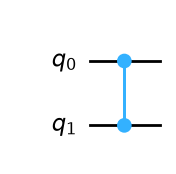

In [3]:
oracle_11 = QuantumCircuit(2, name="Oracle(|11>)")
oracle_11.cz(0, 1)
oracle_11.draw("mpl")

### Marking an arbitrary target state

What if the winner isn't $|11\rangle$ but, say, $|01\rangle$? The trick: sandwich a multi-controlled-Z gate between `X` gates on the qubits that should be `0` in the target. This temporarily "flips" those qubits so the all-ones pattern lines up with our target, applies the phase flip, then flips them back.

Let's write a general function that builds an oracle for *any* target bitstring, on *any* number of qubits.

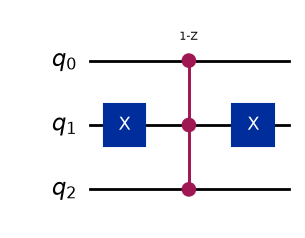

In [4]:
def grover_oracle(n_qubits: int, target: str) -> QuantumCircuit:
    """Return an oracle circuit that flips the phase of the |target> basis state.

    target is a bitstring like "101", read left-to-right as qubit n-1 ... qubit 0
    (Qiskit's little-endian convention: target[-1] corresponds to qubit 0).
    """
    if len(target) != n_qubits:
        raise ValueError("target bitstring length must equal n_qubits")

    qc = QuantumCircuit(n_qubits, name=f"Oracle(|{target}>)")

    # target[-1] is qubit 0, target[-2] is qubit 1, etc.
    zero_qubits = [i for i, bit in enumerate(reversed(target)) if bit == "0"]

    # Flip 0-bits to 1 so the target becomes the all-ones pattern
    if zero_qubits:
        qc.x(zero_qubits)

    # Apply a phase flip when ALL qubits are |1>
    if n_qubits == 1:
        qc.z(0)
    else:
        qc.append(MCMTGate(ZGate(), n_qubits - 1, 1), range(n_qubits))

    # Undo the flips
    if zero_qubits:
        qc.x(zero_qubits)

    return qc


# Sanity check: oracle for target "101" on 3 qubits
oracle_demo = grover_oracle(3, "101")
oracle_demo.draw("mpl")

Let's verify this oracle actually does what we claim: it should leave every basis state's amplitude alone *except* flip the sign of $|101\rangle$.

In [5]:
for label in ["000", "001", "010", "011", "100", "101", "110", "111"]:
    sv = Statevector.from_label(label)
    sv_after = sv.evolve(oracle_demo)
    # The dominant amplitude (largest magnitude) tells us the sign picked up;
    # other entries are numerically ~0 but not exactly 0 due to gate decomposition.
    idx = np.argmax(np.abs(sv_after.data))
    amp = sv_after.data[idx]
    print(f"|{label}> -> phase factor {amp.real:+.0f}")

|000> -> phase factor +1
|001> -> phase factor +1
|010> -> phase factor +1
|011> -> phase factor +1
|100> -> phase factor +1
|101> -> phase factor -1
|110> -> phase factor +1
|111> -> phase factor +1


Exactly as expected: only $|101\rangle$ picks up a $-1$ phase. Every other state is untouched. This is our oracle working correctly.

## 4. Building block 2: the Diffuser

The diffuser reflects the state about the uniform superposition $|s\rangle$:

$$
U_s = 2|s\rangle\langle s| - I
$$

**Recipe: H, oracle-about-zero, H.** The middle step is *identical in structure* to the oracle we just built, with target $= |0\rangle^{\otimes n}$:

![Oracle vs. diffuser circuit structure](image/oracle_diffuser_contrast.png)

**The diffuser is just an oracle for the all-zero string, wrapped in Hadamards** — nice code reuse.

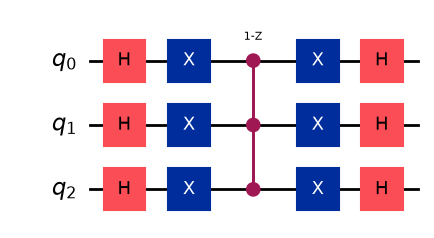

In [6]:
def grover_diffuser(n_qubits: int) -> QuantumCircuit:
    """Return the Grover diffusion operator (inversion about the mean) on n_qubits."""
    qc = QuantumCircuit(n_qubits, name="Diffuser")

    qc.h(range(n_qubits))
    # Reuse our oracle builder: mark the |00...0> state, which after the
    # surrounding Hadamards implements "reflect about |s>"
    qc.compose(grover_oracle(n_qubits, "0" * n_qubits), inplace=True)
    qc.h(range(n_qubits))

    return qc


grover_diffuser(3).draw("mpl")

## 5. Putting it together: the full Grover circuit

![Grover circuit flow: H, then repeated oracle+diffuser, then measure](image/grover_iteration_flow.png)

### How many iterations, $r$?

Each iteration rotates the state by $2\theta$, $\sin\theta = 1/\sqrt{N}$. We want the total rotation as close to $90°$ as possible:

$$
r \approx \left\lfloor \frac{\pi}{4}\sqrt{N} \right\rfloor
$$

This $\sqrt{N}$ scaling is exactly where Grover's speedup comes from.

N = 8 states, optimal iterations r = 2


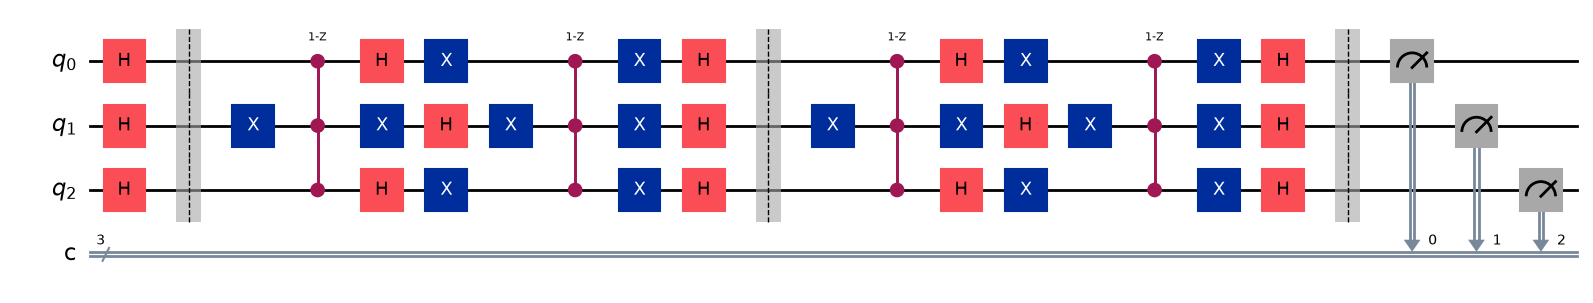

In [7]:
def grover_circuit(n_qubits: int, target: str, iterations: int = None) -> QuantumCircuit:
    """Build the full Grover search circuit for a single marked target."""
    N = 2 ** n_qubits
    if iterations is None:
        iterations = max(1, int(np.floor(np.pi / 4 * np.sqrt(N))))

    qc = QuantumCircuit(n_qubits, n_qubits, name="Grover")

    # Step 1: uniform superposition
    qc.h(range(n_qubits))
    qc.barrier()

    # Step 2: repeated oracle + diffuser
    oracle = grover_oracle(n_qubits, target)
    diffuser = grover_diffuser(n_qubits)
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
        qc.barrier()

    # Step 3: measure
    qc.measure(range(n_qubits), range(n_qubits))

    return qc


n_qubits = 3
target = "101"
N = 2 ** n_qubits
optimal_r = max(1, int(np.floor(np.pi / 4 * np.sqrt(N))))
print(f"N = {N} states, optimal iterations r = {optimal_r}")

qc = grover_circuit(n_qubits, target)
qc.draw("mpl")

## 6. Running the algorithm

Let's run this on Qiskit Aer's simulator using the `SamplerV2` primitive (the modern, recommended way to get measurement results in Qiskit 2.x) and look at the results.

Measurement counts: {'101': 1892, '100': 15, '010': 21, '011': 16, '110': 16, '001': 12, '000': 13, '111': 15}


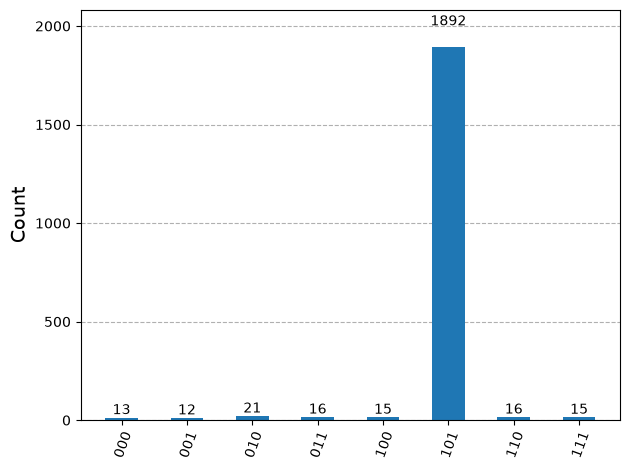

In [8]:
simulator = AerSimulator()
sampler = Sampler()

qc_isa = transpile(qc, backend=simulator)
job = sampler.run([qc_isa], shots=2000)
result = job.result()
counts = result[0].data.c.get_counts()

print("Measurement counts:", counts)
plot_histogram(counts)

You should see the bar for `101` towering over all the others — often above 90-95% probability, even though we're searching among 8 equally likely possibilities. That's Grover's algorithm working: a single quantum circuit run, with **only 2 oracle calls**, finds the marked item with high confidence, versus a classical average of ~4 checks (and up to 8 in the worst case) for this tiny example. The gap becomes dramatic as $N$ grows.

## 7. What if we pick the wrong number of iterations?

Remember the geometric picture: each iteration rotates the state vector by a fixed angle. If we rotate too little, we haven't reached the winner yet. If we rotate too much, we **overshoot past it** and probability starts dropping again! Let's sweep over several iteration counts and watch the success probability rise and fall.

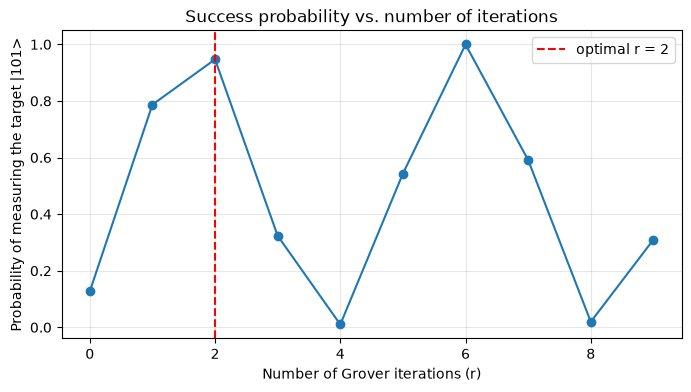

In [9]:
success_probs = []
iteration_range = range(0, 10)

for r in iteration_range:
    test_qc = grover_circuit(n_qubits, target, iterations=r)
    test_qc_isa = transpile(test_qc, backend=simulator)
    job = sampler.run([test_qc_isa], shots=2000)
    counts = job.result()[0].data.c.get_counts()
    prob = counts.get(target, 0) / sum(counts.values())
    success_probs.append(prob)

plt.figure(figsize=(8, 4))
plt.plot(list(iteration_range), success_probs, marker="o")
plt.axvline(optimal_r, color="red", linestyle="--", label=f"optimal r = {optimal_r}")
plt.xlabel("Number of Grover iterations (r)")
plt.ylabel(f"Probability of measuring the target |{target}>")
plt.title("Success probability vs. number of iterations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Notice the curve rises, peaks near our computed optimal $r$, then **falls back down** and would eventually oscillate if we kept going. This is the rotation picture in action — the state vector sweeps past $|w\rangle$ and heads back toward $|s'\rangle$ if you keep iterating. Choosing $r$ correctly matters!

## 8. Bonus: searching for multiple winners

Grover's algorithm generalizes easily to the case where there are $M \geq 1$ winning states out of $N$. The optimal number of iterations becomes:

$$
r \approx \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor
$$

The oracle just needs to flip the phase of *all* winning states. Let's search for two targets at once: `"101"` and `"010"`.

Using 1 iteration(s) for 2 targets
Measurement counts: {'010': 1024, '101': 976}


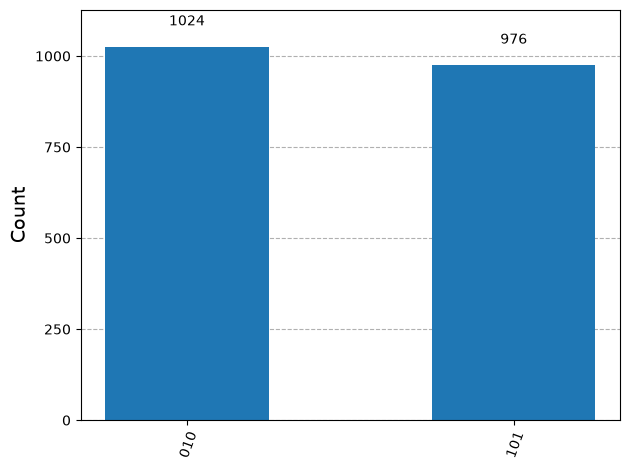

In [10]:
def grover_oracle_multi(n_qubits: int, targets: list[str]) -> QuantumCircuit:
    """Oracle that flips the phase of every state listed in `targets`."""
    qc = QuantumCircuit(n_qubits, name="Oracle(multi)")
    for t in targets:
        qc.compose(grover_oracle(n_qubits, t), inplace=True)
    return qc


def grover_circuit_multi(n_qubits: int, targets: list[str], iterations: int = None) -> QuantumCircuit:
    N = 2 ** n_qubits
    M = len(targets)
    if iterations is None:
        iterations = max(1, int(np.floor(np.pi / 4 * np.sqrt(N / M))))

    qc = QuantumCircuit(n_qubits, n_qubits, name="Grover-multi")
    qc.h(range(n_qubits))
    qc.barrier()

    oracle = grover_oracle_multi(n_qubits, targets)
    diffuser = grover_diffuser(n_qubits)
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
        qc.barrier()

    qc.measure(range(n_qubits), range(n_qubits))
    return qc


targets = ["101", "010"]
qc_multi = grover_circuit_multi(3, targets)
print(f"Using {max(1, int(np.floor(np.pi / 4 * np.sqrt(8 / 2))))} iteration(s) for {len(targets)} targets")
qc_multi_isa = transpile(qc_multi, backend=simulator)

job = sampler.run([qc_multi_isa], shots=2000)
counts_multi = job.result()[0].data.c.get_counts()
print("Measurement counts:", counts_multi)
plot_histogram(counts_multi)

Both `101` and `010` should now dominate the histogram, each getting roughly half of the total "winning" probability, while every other state stays suppressed.

## 9. Bonus: building an oracle from logical rules (a Minesweeper puzzle)

Every oracle we've built so far — `grover_oracle(n_qubits, target)` — is handed the answer directly: you pass in the winning bitstring `target`, and the function just wires up gates that recognize *that specific string*. That's fine for learning the mechanics, but it sidesteps the real point of Grover's algorithm: in practice, you almost never know the answer in advance. What you have is a *rule* that lets you check whether a candidate is correct, and Grover's algorithm searches through candidates for you.

Let's build a genuine example of this: a **Minesweeper puzzle**. We have a 4×4 board. Some cells are already revealed and show a number (how many mines are hiding among that cell's up-to-8 neighbors). Other cells are unknown — they might be mines or might be safe, and we don't know which.

We'll treat each unknown cell as one qubit (`1` = mine, `0` = safe), and build an oracle that flips the phase of a candidate assignment **if and only if it's consistent with every revealed number** — computed purely from the board's geometry and the clue numbers, never from knowing the actual mine locations ahead of time.</cell id="mine-intro-header">


### The puzzle

Here's the board we'll solve. Revealed cells show their clue number; unknown cells are labeled with the qubit index that represents them.

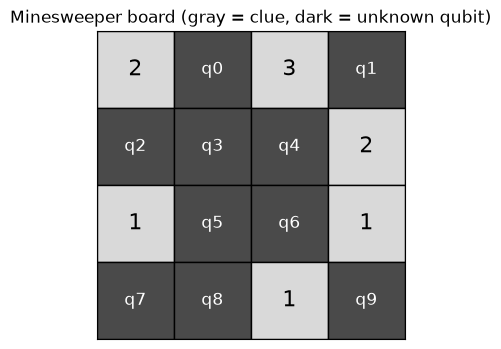

In [11]:
CLUES = {(0, 0): 2, (0, 2): 3, (1, 3): 2, (2, 0): 1, (2, 3): 1, (3, 2): 1}
UNKNOWN_CELLS = [(0, 1), (0, 3), (1, 0), (1, 1), (1, 2), (2, 1), (2, 2), (3, 0), (3, 1), (3, 3)]

fig, ax = plt.subplots(figsize=(4, 4))
for r in range(4):
    for c in range(4):
        if (r, c) in CLUES:
            ax.add_patch(plt.Rectangle((c, 3 - r), 1, 1, facecolor="#d9d9d9", edgecolor="black"))
            ax.text(c + 0.5, 3 - r + 0.5, str(CLUES[(r, c)]), ha="center", va="center", fontsize=16)
        else:
            q = UNKNOWN_CELLS.index((r, c))
            ax.add_patch(plt.Rectangle((c, 3 - r), 1, 1, facecolor="#4a4a4a", edgecolor="black"))
            ax.text(c + 0.5, 3 - r + 0.5, f"q{q}", ha="center", va="center", fontsize=12, color="white")

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
ax.set_title("Minesweeper board (gray = clue, dark = unknown qubit)")
plt.show()

### From board geometry to clue constraints

Each clue's number counts mines among its up-to-8 neighboring cells (including diagonals), clipped to the board edges. For each clue cell, we look at its neighbors, keep only the ones that are still unknown (the revealed clue cells themselves are never mines), and note which qubit index each corresponds to. This gives us, for every clue, a pair `(k, neighbor_qubits)`: "exactly `k` of these qubits must be 1."

We compute this table once from the board — never from knowing where the mines actually are:

| Clue cell | k (mines) | neighbor qubits | degree |
|---|---|---|---|
| (0,0) | 2 | q0, q2, q3 | 3 |
| (0,2) | 3 | q0, q1, q3, q4 | 4 |
| (1,3) | 2 | q1, q4, q6 | 3 |
| (2,0) | 1 | q2, q3, q5, q7, q8 | 5 |
| (2,3) | 1 | q4, q6, q9 | 3 |
| (3,2) | 1 | q5, q6, q8, q9 | 4 |

In [12]:
def neighbors(cell):
    r, c = cell
    return [
        (r + dr, c + dc)
        for dr in (-1, 0, 1)
        for dc in (-1, 0, 1)
        if (dr, dc) != (0, 0) and 0 <= r + dr < 4 and 0 <= c + dc < 4
    ]


CLUE_SPECS = []
for cell, k in CLUES.items():
    neighbor_qubits = [UNKNOWN_CELLS.index(n) for n in neighbors(cell) if n in UNKNOWN_CELLS]
    CLUE_SPECS.append((k, sorted(neighbor_qubits)))
    print(f"clue {cell} = {k}  ->  neighbor qubits {sorted(neighbor_qubits)}")

clue (0, 0) = 2  ->  neighbor qubits [0, 2, 3]
clue (0, 2) = 3  ->  neighbor qubits [0, 1, 3, 4]
clue (1, 3) = 2  ->  neighbor qubits [1, 4, 6]
clue (2, 0) = 1  ->  neighbor qubits [2, 3, 5, 7, 8]
clue (2, 3) = 1  ->  neighbor qubits [4, 6, 9]
clue (3, 2) = 1  ->  neighbor qubits [5, 6, 8, 9]


Before building the quantum oracle, let's sanity-check the puzzle itself: does exactly one mine layout satisfy all six clues at once? This is pure classical brute force — it has nothing to do with the oracle we're about to build, it just confirms the puzzle is well-posed.

In [13]:
import itertools

solutions = []
for bits in itertools.product([0, 1], repeat=10):
    if all(sum(bits[q] for q in qubits) == k for k, qubits in CLUE_SPECS):
        solutions.append(bits)

print(f"Found {len(solutions)} solution(s) out of 1024 possible mine layouts.")
solution_bits = solutions[0]
mine_qubits = [q for q, b in enumerate(solution_bits) if b == 1]
print(f"Unique solution: mines at qubits {mine_qubits} -> cells {[UNKNOWN_CELLS[q] for q in mine_qubits]}")

Found 1 solution(s) out of 1024 possible mine layouts.
Unique solution: mines at qubits [0, 1, 3, 6] -> cells [(0, 1), (0, 3), (1, 1), (2, 2)]


Exactly one out of 1024 possible mine layouts satisfies all six clues — this is the state Grover's algorithm should find for us. But notice: the oracle we build next is never told this bitstring. It only ever sees `CLUE_SPECS` — the `(k, neighbor_qubits)` pairs computed straight from the board.

### Contrast with `grover_oracle`

![grover_oracle is a lookup table; minesweeper_oracle is a checker circuit](image/lookup_vs_checker.png)

- `grover_oracle(n_qubits, target)`: receives the winning bitstring directly, marks exactly that string.
- `minesweeper_oracle`: receives only clue numbers + adjacency, and *computes* whether a candidate satisfies every clue before flipping its phase. This is the template for real Grover applications — SAT solving, graph coloring, scheduling — where you write a **checker circuit**, not a lookup table.

### Building block: "exactly k of d" flag

Each clue needs a small circuit that raises a flag qubit to `1` exactly when precisely `k` of its `d` neighbor qubits are `1`. Here's the trick: for every one of the $\binom{d}{k}$ ways to choose *which* `k` of the `d` qubits are the mines, temporarily flip the remaining `d - k` qubits (so "should be safe" lines up with `0`), apply a single `d`-controlled-X onto the flag, then flip back. This is exactly the same "X-sandwich + multi-controlled gate" trick `grover_oracle` already uses — we're just repeating it once per matching pattern.

Since any real input can only ever match *one* such pattern (a bitstring either has Hamming weight `k` or it doesn't, and if it does, exactly one "which positions are the 1s" pattern fits), the flag toggles at most once, so a plain MCX is enough — no risk of double-toggling back to 0.

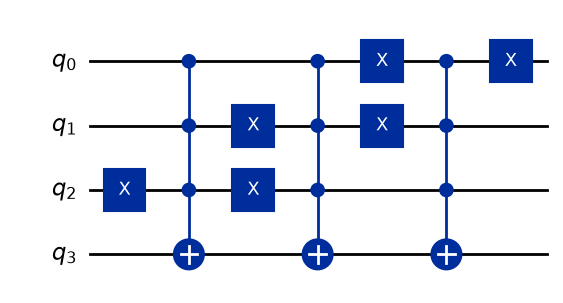

In [14]:
def append_exactly_k_flag(qc: QuantumCircuit, inputs: list[int], flag: int, k: int) -> None:
    """Toggle `flag` iff exactly k of the qubits in `inputs` are |1>."""
    d = len(inputs)
    for subset in itertools.combinations(range(d), k):
        zero_qubits = [inputs[j] for j in range(d) if j not in subset]
        if zero_qubits:
            qc.x(zero_qubits)
        qc.mcx(inputs, flag)
        if zero_qubits:
            qc.x(zero_qubits)


# Demo: d=3 inputs (qubits 0,1,2), k=2, flag on qubit 3
demo = QuantumCircuit(4, name="exactly_2_of_3")
append_exactly_k_flag(demo, inputs=[0, 1, 2], flag=3, k=2)
demo.draw("mpl")

Let's verify this sub-circuit does exactly what we claim, for every possible input.

In [15]:
all_correct = True
for bits in itertools.product([0, 1], repeat=3):
    # qubit0=bits[0], qubit1=bits[1], qubit2=bits[2], flag qubit3 starts at 0
    # Statevector.from_label reads left-to-right as qubit (n-1)...qubit 0
    label = "0" + str(bits[2]) + str(bits[1]) + str(bits[0])
    sv = Statevector.from_label(label)
    sv_after = sv.evolve(demo)
    outcome = max(sv_after.probabilities_dict(), key=sv_after.probabilities_dict().get)
    measured_flag = int(outcome[0])  # leftmost char = qubit 3 (flag)
    expected_flag = 1 if sum(bits) == 2 else 0
    ok = measured_flag == expected_flag
    all_correct &= ok
    print(f"inputs={bits} -> flag={measured_flag} (expected {expected_flag}) {'OK' if ok else 'MISMATCH'}")

print("\nAll cases correct!" if all_correct else "\nSomething is wrong!")

inputs=(0, 0, 0) -> flag=0 (expected 0) OK
inputs=(0, 0, 1) -> flag=0 (expected 0) OK
inputs=(0, 1, 0) -> flag=0 (expected 0) OK
inputs=(0, 1, 1) -> flag=1 (expected 1) OK
inputs=(1, 0, 0) -> flag=0 (expected 0) OK
inputs=(1, 0, 1) -> flag=1 (expected 1) OK
inputs=(1, 1, 0) -> flag=1 (expected 1) OK
inputs=(1, 1, 1) -> flag=0 (expected 0) OK

All cases correct!


### Assembling the full oracle

Combine six "exactly k of d" flags — one per clue — into the full Minesweeper oracle:

1. **Compute**: raise each clue's flag ancilla iff that clue's constraint holds. → 6 flags, each `1` iff its clue is satisfied.
2. **Combine**: flip the global phase iff *all six* flags are `1` — one multi-controlled-Z across the flag register.
3. **Uncompute**: re-run step 1 to reset every flag back to `0` (each construction is its own inverse).

**10 primary qubits + 6 flag ancillas = 16 qubits total.**

In [16]:
def minesweeper_oracle(clue_specs: list[tuple[int, list[int]]]) -> QuantumCircuit:
    """Build a Grover oracle that flips the phase of any 10-qubit assignment
    satisfying every Minesweeper clue.

    clue_specs: list of (k, neighbor_qubit_indices) — one per clue, describing only
    the puzzle's geometry and clue numbers. The solution itself is never passed in.

    Returns a circuit on 10 + len(clue_specs) qubits: qubits 0..9 are the primary
    register (unknown cells), and each subsequent qubit is a flag ancilla for one clue.
    """
    n_primary = 10
    n_clues = len(clue_specs)
    flags = list(range(n_primary, n_primary + n_clues))

    qc = QuantumCircuit(n_primary + n_clues, name="Oracle(Minesweeper)")

    # Compute: raise each clue's flag iff its constraint holds
    for flag, (k, neighbor_qubits) in zip(flags, clue_specs):
        append_exactly_k_flag(qc, neighbor_qubits, flag, k)

    # Combine: flip phase iff ALL flags are 1
    qc.append(MCMTGate(ZGate(), n_clues - 1, 1), flags)

    # Uncompute: reset every flag ancilla back to |0>
    for flag, (k, neighbor_qubits) in zip(flags, clue_specs):
        append_exactly_k_flag(qc, neighbor_qubits, flag, k)

    return qc


mine_oracle = minesweeper_oracle(CLUE_SPECS)
print(f"Oracle circuit: {mine_oracle.num_qubits} qubits, {mine_oracle.size()} gates, depth {mine_oracle.depth()}")

Oracle circuit: 16 qubits, 237 gates, depth 79


Let's verify the oracle flips the phase on exactly the expected solution, and only that solution — and that all six ancillas really do return to `|0\rangle`. Since looping `Statevector.evolve` once per basis state (as we did for the small 3-qubit oracle earlier) would mean re-simulating a 16-qubit, ~200-gate circuit 1024 times, we instead evolve a *single* state: the equal superposition of all 1024 primary-register combinations with all ancillas at `0`. One `evolve` call checks every case at once.

In [17]:
init = QuantumCircuit(16)
init.h(range(10))  # equal superposition over all 1024 primary states; ancillas stay at |0>

sv_after = Statevector(init).evolve(mine_oracle)
amplitudes = sv_after.data

flipped = [i for i in range(1024) if amplitudes[i].real < -1e-6]
ancilla_leakage = np.sum(np.abs(amplitudes[1024:]) ** 2)

print(f"States with a flipped phase: {flipped}")
flipped_bits = [(flipped[0] >> q) & 1 for q in range(10)]
print(f"That state's mine qubits: {[q for q, b in enumerate(flipped_bits) if b]}")
print(f"Matches classical solution (mines at {mine_qubits})? {sorted(q for q, b in enumerate(flipped_bits) if b) == sorted(mine_qubits)}")
print(f"Probability leaked into ancilla-nonzero states: {ancilla_leakage:.2e} (should be ~0)")

States with a flipped phase: [75]
That state's mine qubits: [0, 1, 3, 6]
Matches classical solution (mines at [0, 1, 3, 6])? True
Probability leaked into ancilla-nonzero states: 4.80e-30 (should be ~0)


Exactly one state picks up a `-1` phase, it matches the classical brute-force solution from earlier, and no probability leaked into the ancilla register. `minesweeper_oracle` is a clean phase oracle — built entirely from the clue geometry, never from the answer.

### Running Grover's algorithm on the Minesweeper oracle

- Reuse `grover_diffuser` unchanged — it only touches the primary 10-qubit register.
- $N = 2^{10} = 1024$, single winner → $r \approx \lfloor \frac{\pi}{4}\sqrt{1024} \rfloor = 25$.
- Circuit needs 16 qubits (10 primary + 6 ancillas) but only 10 classical bits — we measure just the primary register.

N = 1024, optimal iterations r = 25
Most measured bitstring: 0001001011 (1999/2000 shots)


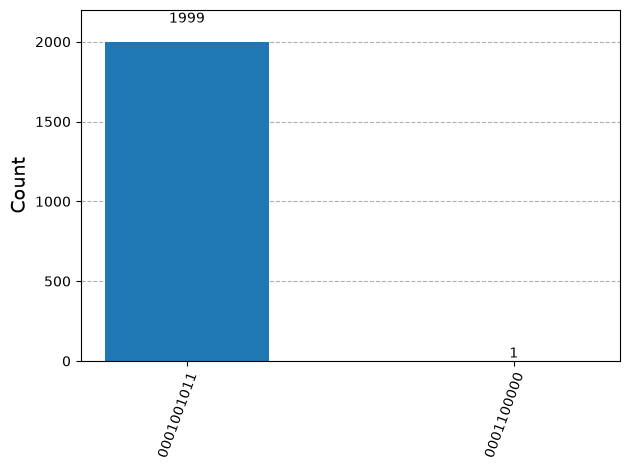

In [18]:
N_mine = 2 ** 10
r_mine = max(1, int(np.floor(np.pi / 4 * np.sqrt(N_mine))))
print(f"N = {N_mine}, optimal iterations r = {r_mine}")

qc_mine = QuantumCircuit(16, 10, name="Grover-Minesweeper")
qc_mine.h(range(10))
qc_mine.barrier()

diffuser10 = grover_diffuser(10)
for _ in range(r_mine):
    qc_mine.compose(mine_oracle, qubits=range(16), inplace=True)
    qc_mine.compose(diffuser10, qubits=range(10), inplace=True)
    qc_mine.barrier()

qc_mine.measure(range(10), range(10))

qc_mine_isa = transpile(qc_mine, backend=simulator)
job = sampler.run([qc_mine_isa], shots=2000)
counts_mine = job.result()[0].data.c.get_counts()

top_result = max(counts_mine, key=counts_mine.get)
print(f"Most measured bitstring: {top_result} ({counts_mine[top_result]}/{sum(counts_mine.values())} shots)")
plot_histogram(counts_mine)

In [19]:
winning_bits = [int(b) for b in reversed(top_result)]
found_mines = [UNKNOWN_CELLS[q] for q, b in enumerate(winning_bits) if b == 1]
print(f"Grover found mines at: {found_mines}")
print(f"Classical brute force found mines at: {[UNKNOWN_CELLS[q] for q in mine_qubits]}")

Grover found mines at: [(0, 1), (0, 3), (1, 1), (2, 2)]
Classical brute force found mines at: [(0, 1), (0, 3), (1, 1), (2, 2)]


The winning bitstring dominates the histogram (well above 90% of shots out of 1024 equally likely candidates), and it matches the classical brute-force solution — found by a genuinely *logical* oracle that was only ever given clue numbers and adjacency, never the mine locations themselves. This is the pattern behind every real-world use of Grover's algorithm: write a checker circuit for your constraints, and let amplitude amplification do the searching.

## 10. Recap and key takeaways

| Concept | What it does |
|---|---|
| **Uniform superposition** ($H^{\otimes n}$) | Puts all $N$ possibilities into play simultaneously |
| **Oracle** | Flips the phase (sign) of the winning state(s), marking them invisibly |
| **Diffuser** | Reflects about the average amplitude, turning the phase flip into a boosted probability |
| **One Grover iteration** (oracle + diffuser) | Rotates the state vector by a fixed angle toward the winner |
| **Optimal iteration count** $r \approx \frac{\pi}{4}\sqrt{N/M}$ | Stops the rotation right when it's aligned with the winner(s) — too few or too many iterations both hurt |

**Why this matters beyond search:** the oracle + diffuser pattern ("amplitude amplification") is a general-purpose quantum subroutine. It's reused inside many other algorithms — quantum counting, quantum walks, and various optimization and machine-learning algorithms all borrow this same amplify-the-good-answers trick.

### Where to go next

- Try building an oracle for a *computed* condition (e.g., "mark $x$ if $x$ is even") instead of a fixed bitstring — this is how Grover's algorithm is used for real problems like SAT-solving. (We did exactly this in the Minesweeper bonus section above — see how a checker built from puzzle rules, not a hardcoded answer, still lets Grover find the unique solution.)
- Look up **quantum counting**, which uses phase estimation on top of the Grover iterate to estimate $M$ (the number of winners) without knowing it in advance.
- Try running your circuit on real IBM Quantum hardware via `qiskit-ibm-runtime`, and compare the noisy real-device histogram to the ideal simulator one from this notebook.